In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.patches import Patch
import xarray as xr
import cartopy.crs as ccrs

In [2]:
ds = xr.open_dataset("GEOS-CF_AirQuality_20180101_0030z.nc4")

In [3]:
ds

<xarray.Dataset> Size: 21MB
Dimensions:        (time: 1, lev: 1, lat: 721, lon: 1440)
Coordinates:
  * time           (time) datetime64[ns] 8B 2018-01-01T00:30:00
  * lev            (lev) float64 8B 72.0
  * lat            (lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * lon            (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
Data variables:
    CO             (time, lev, lat, lon) float32 4MB ...
    NO2            (time, lev, lat, lon) float32 4MB ...
    O3             (time, lev, lat, lon) float32 4MB ...
    PM25_RH35_GCC  (time, lev, lat, lon) float32 4MB ...
    SO2            (time, lev, lat, lon) float32 4MB ...
Attributes: (12/28)
    Contact:               http://gmao.gsfc.nasa.gov
    History:               Original file generated: Mon Dec 24 13:37:28 2018 GMT
    Source:                cak_Icarus-1_0_GCCv12-00-01_v1_010 experiment_id: ...
    Conventions:           CF-1
    Title:                 GEOS CF (Composition Forecast)
    Institution:           NASA Global Modeling and Assimilation Office
    ...                    ...
    DataResolution:        0.25 x 0.25
    LongName:              GEOS CF 2d time-averaged air quality concentration...
    ShortName:             CF01Raqc_1hrT_g1440x721_V1
    Comment:               GMAO filename: c360_GEOS-CF.chm_tavg_1hr_g1440x721...
    Filename:              GEOS-CF.v01.rpl.aqc_tavg_1hr_g1440x721_v1.20180101...
    GranuleID:             GEOS-CF.v01.rpl.aqc_tavg_1hr_g1440x721_v1.20180101...

In [4]:
O3 = ds.O3

In [5]:
print("Minimum:", O3.min().values)
print("Maximum:", O3.max().values)

Minimum: 0.0
Maximum: 6.973277777433395e-08


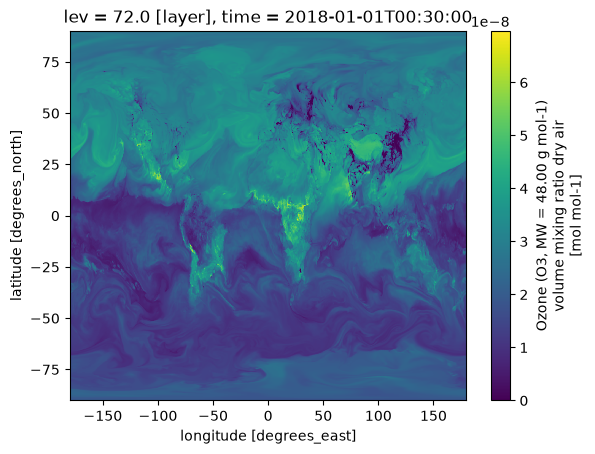

In [6]:
O3.plot()
plt.show()

In [7]:
# Select the time and vertical layer
O3_raw = ds.O3.isel(time=0, lev=0)

O3 = O3_raw * 1e9

print("Minimum:", O3.min().values)
print("Maximum:", O3.max().values)

Minimum: 0.0
Maximum: 69.73278045654297


/opt/anaconda3/envs/geol415/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/opt/anaconda3/envs/geol415/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


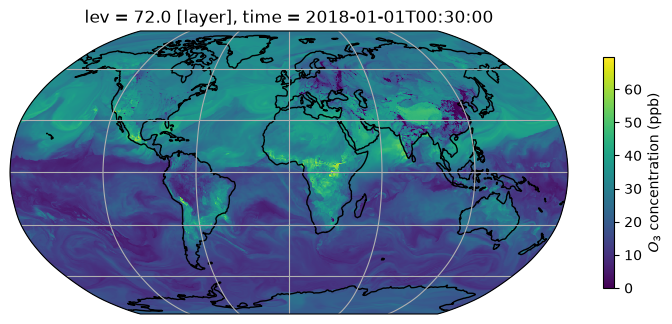

In [8]:
fig = plt.figure(figsize=(9,6))
ax = plt.axes(projection=ccrs.Robinson())
O3.plot(ax=ax, transform=ccrs.PlateCarree(), 
        cbar_kwargs={'shrink': 0.5,
        "label": r"$O_3$ concentration (ppb)"})
ax.coastlines()
ax.gridlines()
plt.show()

In [9]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="invalid value encountered in create_collection",
    category=RuntimeWarning,
    module=r"shapely\.creation"
)

I don't need a log scale plot because in linear scale the plot looks good and the data range is not too wide.

In [10]:
# Combine latitude and longitude into one dimension
stacked = O3.stack(point=("lat", "lon")).dropna("point")

maximum = stacked.isel(
    point=stacked.argmax(dim="point")
)

minimum = stacked.isel(
    point=stacked.argmin(dim="point")
)

max_value = float(maximum.values)
max_lat = float(maximum.lat.values)
max_lon = float(maximum.lon.values)

min_value = float(minimum.values)
min_lat = float(minimum.lat.values)
min_lon = float(minimum.lon.values)

print("HIGHEST OZONE")
print(f"Concentration: {max_value:.2f} ppb")
print(f"Coordinates: {max_lat:.2f}°, {max_lon:.2f}°")
#print(f"Longitude: {max_lon:.2f}°")

print("\nLOWEST OZONE")
print(f"Concentration: {min_value:.2f} ppb")
print(f"Latitude: {min_lat:.2f}°")
print(f"Longitude: {min_lon:.2f}°")

HIGHEST OZONE
Concentration: 69.73 ppb
Coordinates: 34.50°, -118.75°

LOWEST OZONE
Concentration: 0.00 ppb
Latitude: 53.00°
Longitude: 73.25°


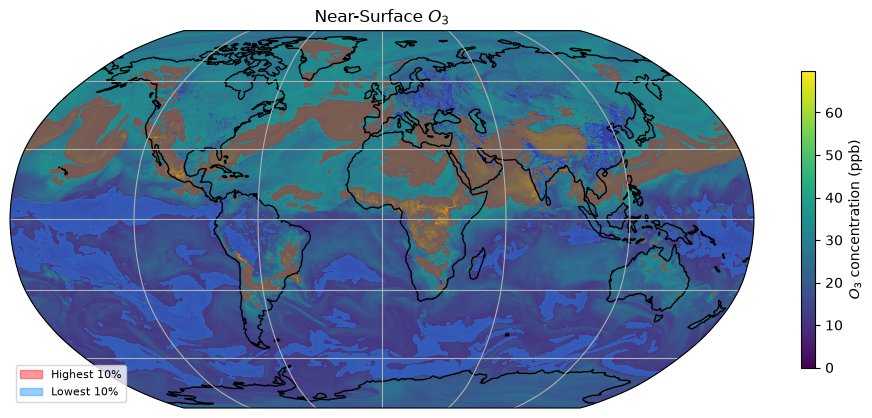

QUALITATIVELY HIGH OZONE
Red-shaded areas contain the highest 10% of values (O3 ≥ 34.92 ppb).

QUALITATIVELY LOW OZONE
Blue-shaded areas contain the lowest 10% of values (O3 ≤ 10.78 ppb).


In [11]:
# Highest 10% and lowest 10% of Ozone values

high_threshold = float(O3.quantile(0.90))
low_threshold = float(O3.quantile(0.10))


fig = plt.figure(figsize=(12, 7))
ax = plt.axes(projection=ccrs.Robinson())

# Plot O3 concentration

O3.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="viridis",
    cbar_kwargs={
        "shrink": 0.55,
        "label": r"$O_3$ concentration (ppb)"
    }
)

# Highlight the lowest 10% in blue
ax.contourf(
    O3.lon,
    O3.lat,
    O3,
    levels=[float(O3.min()), low_threshold],
    colors=["dodgerblue"],
    alpha=0.45,
    transform=ccrs.PlateCarree()
)

# Highlight the highest 10% in red
ax.contourf(
    O3.lon,
    O3.lat,
    O3,
    levels=[high_threshold, float(O3.max())],
    colors=["red"],
    alpha=0.40,
    transform=ccrs.PlateCarree()
)


ax.coastlines()
ax.gridlines()
ax.set_title(r"Near-Surface $O_3$")

# Add high/low regions to the legend
handles, labels = ax.get_legend_handles_labels()

handles.extend([
    Patch(color="red", alpha=0.40, label="Highest 10%"),
    Patch(color="dodgerblue", alpha=0.45, label="Lowest 10%")
])

ax.legend(
    handles=handles,
    loc="lower left",
    fontsize=8
)

plt.show()

# Print answers
# --------------------------------------------------

print("QUALITATIVELY HIGH OZONE")
print(
    f"Red-shaded areas contain the highest 10% of values "
    f"(O3 ≥ {high_threshold:.2f} ppb)."
)

print("\nQUALITATIVELY LOW OZONE")
print(
    f"Blue-shaded areas contain the lowest 10% of values "
    f"(O3 ≤ {low_threshold:.2f} ppb)."
)

In [12]:
# LA and Hawaii

la_lat, la_lon = 34.05, -118.25
hawaii_lat, hawaii_lon = 21.31, -157.86


O3_LA = O3.sel(lat=la_lat, lon=la_lon, method="nearest")

O3_Hawaii = O3.sel(lat=hawaii_lat, lon=hawaii_lon, method="nearest")

la_value = float(O3_LA.values)
la_grid_lat = float(O3_LA.lat.values)
la_grid_lon = float(O3_LA.lon.values)

hawaii_value = float(O3_Hawaii.values)
hawaii_grid_lat = float(O3_Hawaii.lat.values)
hawaii_grid_lon = float(O3_Hawaii.lon.values)


print("OZONE OVER LOS ANGELES")
print(f"Concentration: {la_value:.2f} ppb")
print(f"Nearest grid point: " f"{la_grid_lat:.2f}°, {la_grid_lon:.2f}°")

print("\nOZONE O3 OVER HAWAII")
print(f"Concentration: {hawaii_value:.2f} ppb")
print(f"Nearest grid point: " f"{hawaii_grid_lat:.2f}°, {hawaii_grid_lon:.2f}°")

OZONE OVER LOS ANGELES
Concentration: 45.40 ppb
Nearest grid point: 34.00°, -118.25°

OZONE O3 OVER HAWAII
Concentration: 35.51 ppb
Nearest grid point: 21.25°, -157.75°


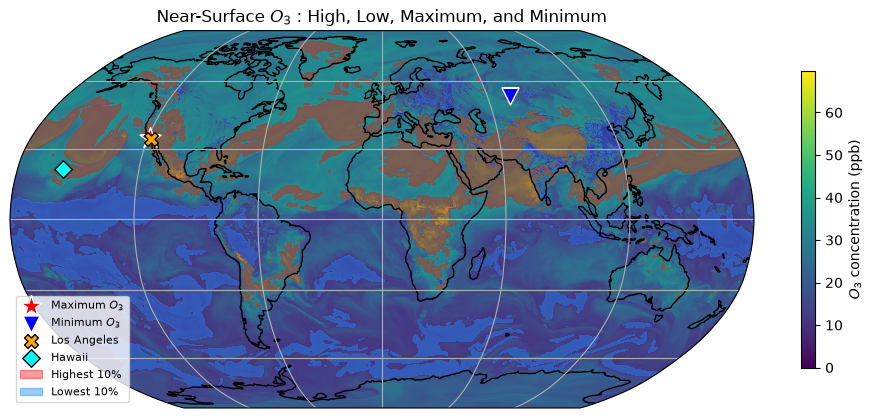

In [18]:
# Integrated Map

fig = plt.figure(figsize=(12, 7))
ax = plt.axes(projection=ccrs.Robinson())

# Plot O3 concentration
O3.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="viridis",
    cbar_kwargs={
        "shrink": 0.55,
        "label": r"$O_3$ concentration (ppb)"
    }
)

# Highlight the lowest 10% in blue
ax.contourf(
    O3.lon,
    O3.lat,
    O3,
    levels=[float(O3.min()), low_threshold],
    colors=["dodgerblue"],
    alpha=0.45,
    transform=ccrs.PlateCarree()
)

# Highlight the highest 10% in red
ax.contourf(
    O3.lon,
    O3.lat,
    O3,
    levels=[high_threshold, float(O3.max())],
    colors=["red"],
    alpha=0.40,
    transform=ccrs.PlateCarree()
)

# Maximum O3
ax.scatter(
    max_lon,
    max_lat,
    marker="*",
    s=250,
    color="red",
    edgecolor="white",
    transform=ccrs.PlateCarree(),
    zorder=10,
    label=r"Maximum $O_3$"
)

# Minimum O3
ax.scatter(
    min_lon,
    min_lat,
    marker="v",
    s=150,
    color="blue",
    edgecolor="white",
    transform=ccrs.PlateCarree(),
    zorder=10,
    label=r"Minimum $O_3$"
)

# Los Angeles
ax.scatter(
    la_grid_lon,
    la_grid_lat,
    marker="X",
    s=100,
    color="orange",
    edgecolor="black",
    transform=ccrs.PlateCarree(),
    zorder=10,
    label="Los Angeles"
)

# Hawaii
ax.scatter(
    hawaii_grid_lon,
    hawaii_grid_lat,
    marker="D",
    s=80,
    color="cyan",
    edgecolor="black",
    transform=ccrs.PlateCarree(),
    zorder=10,
    label="Hawaii"
)

ax.coastlines()
ax.gridlines()
ax.set_title(r"Near-Surface $O_3$ : High, Low, Maximum, and Minimum")

# Add high/low regions to the legend
handles, labels = ax.get_legend_handles_labels()

handles.extend([
    Patch(color="red", alpha=0.40, label="Highest 10%"),
    Patch(color="dodgerblue", alpha=0.45, label="Lowest 10%")
])

ax.legend(
    handles=handles,
    loc="lower left",
    fontsize=8
)
plt.savefig('ozone_plot.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

I’ll be working with one of the climate model datasets, such as CESM CMIP/PlioMIP2/iTraCE/iCESM models. I haven’t decided yet; I need some time to make up my mind. My goal is to cover a longer timescale and compare it with my proxy dataset. I’ll primarily be working with precipitation and temperature data, and my focus will be either South America or the Tibetan region. I’ve found a few datasets on the NCAR GDEX website: https://gdex.ucar.edu

I think the analysis would be regression.

This analysis holds scientific significance because I intend to compare my proxy dataset (not ready yet hope to get some data by the end of this semester) with existing climate model simulations. The integration of paleoclimate proxies with climate modeling is crucial for enhancing our understanding of climate dynamics, such as investigating the influence of natural and anthropogenic forcings on the global climate. 
